In [1]:
import os
import warnings
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler
import torch

import indicators
from indicators import build_models, compute_thresholds, get_reference_points
from attribution import (
    GradientAttribution, IGAttribution, SHAPAttribution,
    DeepLIFTAttribution, VSFAttribution, get_unified_output
)

warnings.filterwarnings("ignore")
os.environ["SHAP_JS"] = "0"

SEED = 1
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = indicators.DEVICE
FEATURE_NAMES = ["Height", "Weight"]

COLOR_NORMAL = "#3F6B9C"
COLOR_OUTLIER = "#8B1A1A"
COLOR_BOUNDARY = "#6C4F8C"

ABS_RATIO_CMAP = plt.cm.YlOrRd



IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
@dataclass
class ExpConfig:
    n_normal: int = 600
    ae_score_mode: str = "joint"  ## "recon"  "latent"
    alpha_t2: float = 0.99
    alpha_ae: float = 0.99
    ae_latent_dim = 1

    ae_epochs: int = 80
    ae_lr: float = 1e-3
    ae_batch_size: int = 256
    ae_patience: int = 20
    ae_min_delta: float = 1e-5
    ae_hidden_dims = (16, 8)

    ae_weight_decay: float = 0
    ae_latent_dim: int = None
    grad_batch_size: int = 256

    ig_steps: int = 40
    shap_bg_size: int = 16

    vsf_step: float = 0.02
    vsf_max_steps: int = 40
    vsf_grad_tol: float = 1e-6

    svdd_degree: int = 2
    svdd_coef0: float = 1
    svdd_nu: float = 0.05
    svdd_kernel: str = "rbf"
    svdd_gamma: float = 0.25  # 👈 之前建议调大防止红线粘连，可以顺便改在这里
    alpha_svdd = 0.99

    fig_dpi: int = 180
    
    # ⭐【正确改法】：这里直接声明默认分辨率（其他普通算法走低分辨率快速通道）
    contour_gridsize: int = 40

In [3]:
CFG = ExpConfig()

SHAP_CACHE = {}
EXPLAIN_CACHE = {}
GRID_CACHE = {}

In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler

def generate_synthetic_data(n_total_normal=650): 
    n1 = n_total_normal // 2
    n2 = n_total_normal - n1
    
    # 稍微拉开距离，避免中间粘连
    mu1 = np.array([-500.0, -500.0]) 
    mu2 = np.array([500.0, 500.0])   
    
    # ⭐ 真正的强正相关性设置！
    # 方差设为 6000，协方差设为 5800（接近方差，相关系数很高）
    # 这样才能生成沿 y=x 分布的“细长”椭圆，而不是散乱的圆
    cov1 = np.array([[6000.0, 58.0], 
                     [58.0, 6000.0]])
                     
    cov2 = np.array([[6000.0, 58.0], 
                     [58, 6000.0]])
    
    X1 = np.random.multivariate_normal(mu1, cov1, n1)
    X2 = np.random.multivariate_normal(mu2, cov2, n2)
    
    x_normal_raw = np.vstack([X1, X2])
    np.random.shuffle(x_normal_raw)
    
    # ⭐ 移除或极大幅度减少“桥梁点”，防止 AE 产生中间连接区
    # 如果必须有，确保它们远离正常数据簇的中心连线
    outliers_bridge = np.empty((0, 2)) # 这里直接清空桥梁点，看是否能解决问题
    
    # 生成外围离群点
    outliers_extreme_raw = np.random.uniform(low=-800.0, high=800.0, size=(300, 2)) 
    
    dist1 = np.linalg.norm(outliers_extreme_raw - mu1, axis=1)
    dist2 = np.linalg.norm(outliers_extreme_raw - mu2, axis=1)
    
    # 加大排除半径，确保异常点绝对不会出现在红圈内部
    mask = (dist1 > 300.0) & (dist2 > 300.0) 
    outliers_extreme = outliers_extreme_raw[mask][:40] 
    
    x_outliers_raw = np.vstack([outliers_bridge, outliers_extreme])
    return x_normal_raw, x_outliers_raw

In [5]:
x_normal_raw, x_outliers_raw = generate_synthetic_data()
scaler = StandardScaler()
scale_factor = 2
x_normal = (scaler.fit_transform(x_normal_raw) * scale_factor).astype(np.float32)
x_outliers = (scaler.transform(x_outliers_raw) * scale_factor).astype(np.float32)

In [6]:
models = build_models(x_normal, config=CFG)
thresholds = compute_thresholds(models, x_normal, config=CFG)
reference_points = get_reference_points(x_normal)

AE Epoch 5/80, MSE Loss: 3.530260
AE Epoch 10/80, MSE Loss: 1.710706
AE Epoch 15/80, MSE Loss: 0.249077
AE Epoch 20/80, MSE Loss: 0.087473
AE Epoch 25/80, MSE Loss: 0.084651
AE Epoch 30/80, MSE Loss: 0.084390
AE Epoch 35/80, MSE Loss: 0.084197
AE Epoch 40/80, MSE Loss: 0.083928
AE Epoch 45/80, MSE Loss: 0.083649
AE Epoch 50/80, MSE Loss: 0.083434
AE Epoch 55/80, MSE Loss: 0.083245
AE Epoch 60/80, MSE Loss: 0.082807
AE Epoch 65/80, MSE Loss: 0.082481
AE Epoch 70/80, MSE Loss: 0.082043
AE Epoch 75/80, MSE Loss: 0.081762
AE Epoch 80/80, MSE Loss: 0.081116


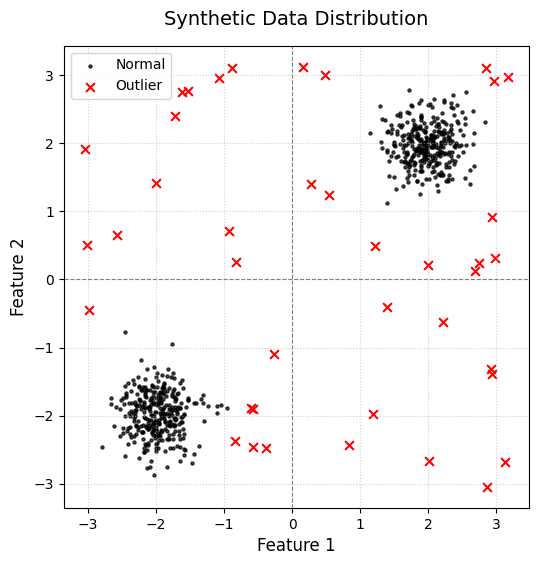

In [7]:
fig, ax = plt.subplots(figsize=(6, 6)) # 创建一个 6x6 英寸的正方形画布

# 绘制正常数据 (黑色小点)
ax.scatter(x_normal[:, 0], x_normal[:, 1], 
           c='black', marker='.', s=20, alpha=0.7, label='Normal')

# 绘制异常数据 (红色叉号)
ax.scatter(x_outliers[:, 0], x_outliers[:, 1], 
           c='red', marker='x', s=40, label='Outlier')

# 图表装饰与格式设置
ax.set_title('Synthetic Data Distribution', fontsize=14, pad=15)
ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)

# 添加过原点的辅助虚线
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8) 
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8) 

ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left')

plt.show()

In [8]:
# ===== 检查 AE score 分布 =====
scores = models["AE"]["score_numpy"](x_normal)

print("\n=== AE score check ===")
print("min:", scores.min())
print("max:", scores.max())
print("mean:", scores.mean())
print("threshold:", thresholds["AE"])

# ===== 检查 AE 真正重构输出 =====
indicator_model = models["AE"]["indicator_model"]

print("\n=== AE model structure ===")
print(indicator_model)
print("available attributes:", indicator_model.__dict__.keys())

x_tensor = torch.tensor(x_normal[:10], dtype=torch.float32).to(DEVICE)

# 注意：indicator_model(x) 输出的是 anomaly score，不是 reconstruction
with torch.no_grad():
    ae_score = indicator_model(x_tensor).detach().cpu().numpy()

print("\nAE indicator output / score:")
print(ae_score)
print("score shape:", ae_score.shape)

# 如果 wrapper 里有真正的 ae_model，才取 reconstruction
if hasattr(indicator_model, "ae_model"):
    ae_net = indicator_model.ae_model

    with torch.no_grad():
        x_rec = ae_net(x_tensor).detach().cpu().numpy()

    print("\ninput:")
    print(x_normal[:10])
    print("input shape:", x_normal[:10].shape)

    print("\nreconstruction:")
    print(x_rec)
    print("recon shape:", x_rec.shape)

else:
    print("\n当前 indicator_model 里没有 ae_model 属性。")
    print("说明 build_models 没有把原始 AE 网络暴露出来。")


=== AE score check ===
min: -0.84690964
max: 6.168253
mean: -5.0494855e-05
threshold: 3.7223958778381343

=== AE model structure ===
UnifiedIndicatorModel(
  (ae_model): RealAE(
    (encoder): Sequential(
      (0): Linear(in_features=2, out_features=16, bias=True)
      (1): Tanh()
      (2): Linear(in_features=16, out_features=8, bias=True)
      (3): Tanh()
      (4): Linear(in_features=8, out_features=4, bias=True)
    )
    (decoder): Sequential(
      (0): Linear(in_features=4, out_features=8, bias=True)
      (1): Tanh()
      (2): Linear(in_features=8, out_features=16, bias=True)
      (3): Tanh()
      (4): Linear(in_features=16, out_features=2, bias=True)
    )
  )
)
available attributes: dict_keys(['training', '_parameters', '_buffers', '_non_persistent_buffers_set', '_backward_pre_hooks', '_backward_hooks', '_is_full_backward_hook', '_forward_hooks', '_forward_hooks_with_kwargs', '_forward_hooks_always_called', '_forward_pre_hooks', '_forward_pre_hooks_with_kwargs', '_stat

In [9]:
def build_all_explainers(
    model_name,
    reference,
    x_normal,
    models,
    method_labels,
    config=None
):
    cfg = config or CFG
    explainers = {}

    indicator_model = models[model_name]["indicator_model"]
    score_numpy_raw = models[model_name]["score_numpy"]

    def score_numpy(x):
        y = score_numpy_raw(x)
        return np.nan_to_num(
            y,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

    ref = np.asarray(reference, dtype=np.float32)

    if ref.ndim == 1:
        ref = ref.reshape(1, -1)

    rng = np.random.default_rng(SEED)

    bg_size = min(
        cfg.shap_bg_size,
        len(x_normal)
    )

    bg_idx = rng.choice(
        len(x_normal),
        size=bg_size,
        replace=False
    )

    background = x_normal[bg_idx]

    for method in method_labels:

        try:

            if method == "Gradient":
                explainers[method] = GradientAttribution(
                    indicator_model
                )

            elif method == "IG":
                explainers[method] = IGAttribution(
                    indicator_model,
                    reference=ref,
                    steps=cfg.ig_steps
                )

            elif method == "SHAP":

                cache_key = (
                    model_name,
                    bg_size
                )


                if cache_key not in SHAP_CACHE:

                    SHAP_CACHE[cache_key] = SHAPAttribution(
                        indicator_model,
                        background
                    )


                explainers[method] = SHAP_CACHE[cache_key]

                explainers[method] = SHAP_CACHE[cache_key]

            elif method == "DeepLIFT":
                explainers[method] = DeepLIFTAttribution(
                    indicator_model,
                    reference=ref
                )

            elif method == "VSF":
                explainers[method] = VSFAttribution(
                    indicator_model,
                    dt=cfg.vsf_step,
                    max_steps=cfg.vsf_max_steps,
                    grad_tol=cfg.vsf_grad_tol
                )

            else:
                raise ValueError(
                    f"Unknown method: {method}"
                )

        except Exception as e:
            print(f"⚠️ {model_name}-{method} failed: {e}")
            explainers[method] = None

    return explainers

In [10]:
def get_boundary(
    model_name,
    models,
    thresholds,
    x_normal
):
    if model_name == "T²":
        return float(thresholds["T²"])

    if model_name == "AE":
        return float(thresholds["AE"])

    if model_name == "SVDD":
        # 原始 OCSVM/SVDD 理论边界：score = -decision_function，边界仍为 0
        return float(thresholds["SVDD"])

    raise ValueError(model_name)

In [11]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"], # STIX 是 Matplotlib 自带的，无需安装，外观极像 Times
    "mathtext.fontset": "stix",    # 让公式字体也匹配
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150
})

In [12]:
def draw_base_layer(
    ax, x_normal, x_outliers, reference_point,
    X, Y, contribution_map, score_map, 
    lv_07, lv_095, lv_9999, boundary, dominance_map=None
):
    import numpy as np
    
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")  

    contribution_map = np.nan_to_num(contribution_map)
    score_map = np.nan_to_num(score_map)
    
    # ⭐【关键调整 3】：levels 固定为 201 层渲染，配合外部的全局网格点数（推荐 400），
    # 能够确保底色的蓝色热力图无论放大多少倍看都如丝般顺滑，不带任何像素色块
    contribution_plot = ax.contourf(
        X, Y, contribution_map,
        levels=np.linspace(0, 1, 201),  
        cmap="Blues",
        vmin=0, vmax=1,
        alpha=1.0,
        zorder=1
    )
    
    # 纯净等高线（隐藏全部数字标签）
    ax.contour(X, Y, score_map, levels=[lv_07], colors=["gray"], linewidths=1.2, linestyles="--", zorder=20)
    ax.contour(X, Y, score_map, levels=[lv_095], colors=["#C68E65"], linewidths=2.0, linestyles="-", zorder=22)
    ax.contour(X, Y, score_map, levels=[lv_9999], colors=["dimgray"], linewidths=1.4, linestyles=":", zorder=21)
    ax.contour(X, Y, score_map, levels=[boundary], colors="red", linewidths=2.8, zorder=25)
    
    if dominance_map is not None:
        if np.min(dominance_map) <= 0 <= np.max(dominance_map):
            ax.contour(X, Y, dominance_map, levels=[0], colors=["#2E7D32"], linewidths=2.0, linestyles="-.", zorder=24)
            
    # 绘制无任何字符的干净数据点
    ax.scatter(x_normal[:, 0], x_normal[:, 1], s=5, c="black", alpha=1, linewidths=0, zorder=15)
    ax.scatter(x_outliers[:, 0], x_outliers[:, 1], s=35, c="brown", marker="x", linewidths=1.2, zorder=17)
    
    ax.tick_params(direction='in', top=True, right=True, which='both')
    
    return contribution_plot

In [13]:
def get_cached_grid(model_name, x_data, gridsize):
    global GRID_CACHE
    if "GRID_CACHE" not in globals():
        GRID_CACHE = {}

    key = (model_name, gridsize)

    if key not in GRID_CACHE:
        margin = 1.0

        # ⭐ 修改点 1：确保生成的背景网格必定能覆盖 [-4.5, 4.5]，避免边缘没颜色
        x_min = min(x_data[:, 0].min() - margin, -4.5)
        x_max = max(x_data[:, 0].max() + margin, 4.5)
        y_min = min(x_data[:, 1].min() - margin, -4.5)
        y_max = max(x_data[:, 1].max() + margin, 4.5)

        xs = np.linspace(x_min, x_max, gridsize)
        ys = np.linspace(y_min, y_max, gridsize)

        X, Y = np.meshgrid(xs, ys)
        grid = np.stack([X.ravel(), Y.ravel()], axis=1)

        GRID_CACHE[key] = (
            X, Y, grid, (x_min, x_max, y_min, y_max)
        )

    return GRID_CACHE[key]

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import torch 

def plot_contribution_maps(
    model_names, method_labels, feature_idx, x_normal, x_outliers,
    models, thresholds, reference_points, config=None,
):
    global EXPLAIN_CACHE
    if "EXPLAIN_CACHE" not in globals():
        EXPLAIN_CACHE = {}
        
    cfg = config or CFG
    feature_name = FEATURE_NAMES[feature_idx]
    
    # 【修改点 1】：将方法标签列表中的 "VSF" 统一转换为 "MVSF" 保证排序与展示一致
    method_labels = ["MVSF" if m == "VSF" else m for m in method_labels]
    n_rows, n_cols = len(method_labels), len(model_names)
    
    # 维持大子图物理画布尺寸
    fig = plt.figure(figsize=(3.5 * n_cols + 1.5, 4.8 * n_rows + 2.5), dpi=cfg.fig_dpi)
    
    # wspace=0.0 横向完全挨着无缝，上下留出充裕大间距
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, 
                           bottom=0.25, top=0.88, 
                           left=0.08, right=0.88, 
                           wspace=0.1, hspace=0.1)
    
    all_points = np.vstack([x_normal, x_outliers])
    model_resources = {}
    
    def _safe_quantile(arr, q):
        try:
            return float(np.quantile(arr, q, method="linear"))
        except TypeError:
            return float(np.quantile(arr, q, interpolation="linear"))
    
    # 1. 基础配置解析
    for model_name in model_names:
        score_numpy = models[model_name]["score_numpy"]
        if model_name == "SVDD":
            indicator_model = models[model_name]["indicator_model"]
            def score_numpy(x, indicator_model=indicator_model):
                x = np.asarray(x, dtype=np.float32)
                with torch.no_grad():
                    xt = torch.tensor(x, dtype=torch.float32).to(DEVICE)
                    y = indicator_model(xt)
                return y.detach().cpu().numpy().reshape(-1)
        
        ref_pt = reference_points[model_name]
        boundary = get_boundary(model_name, models, thresholds, x_normal)
        
        # 默认网格（供普通算法和基本底色轮廓使用）
        X, Y, grid, limits = get_cached_grid(model_name + f"_f{feature_idx}", all_points, cfg.contour_gridsize)
        Z = score_numpy(grid).reshape(X.shape)
        
        normal_scores = np.nan_to_num(score_numpy(x_normal)).reshape(-1)
        lv_07 = _safe_quantile(normal_scores, 0.7)
        lv_095 = _safe_quantile(normal_scores, 0.95)
        lv_9999 = _safe_quantile(normal_scores, 0.9999)
        
        # 【修改点 2】：传入解释器构建函数时，需使用原始键名列表（若含 MVSF 还原为 VSF）
        raw_method_labels = ["VSF" if m == "MVSF" else m for m in method_labels]
        
        model_resources[model_name] = {
            "score_numpy": score_numpy, "ref": ref_pt, "boundary": boundary,
            "X": X, "Y": Y, "grid": grid, "limits": limits, "Z": Z,
            "lv_07": lv_07, "lv_095": lv_095, "lv_9999": lv_9999,
            "explainers": build_all_explainers(model_name, ref_pt, x_normal, models, raw_method_labels, cfg)
        }
        
    cf = None 
    has_dominance = False
    for i, method in enumerate(method_labels):
        for j, model_name in enumerate(model_names):
            print(f"▶️ 当前正在执行: 【{method}】算法应用于【{model_name}】模型", flush=True)
            ax = fig.add_subplot(gs[i, j])
            res = model_resources[model_name]
            
            # 【修改点 3】：底层字典交互兼容性映射
            raw_method_key = "VSF" if method == "MVSF" else method
            
            explainer = res["explainers"][raw_method_key]
            if explainer is None:
                ax.text(0.5, 0.5, "FAILED", ha="center", va="center")
                continue
                
            # ========================================================
            # ⭐ 核心秘密通道：如果当前是 MVSF，强行给它建立一套超高清晰度的独立网格进行计算
            # ========================================================
            if method == "MVSF": # 【修改点 4】判断条件改为新标签 MVSF
                vsf_hd_gridsize = 150  
                X_v, Y_v, grid_v, _ = get_cached_grid(model_name + f"_f{feature_idx}_VSF_HD", all_points, vsf_hd_gridsize)
                Z_v = res["score_numpy"](grid_v).reshape(X_v.shape)
                
                cache_key = (model_name, method, grid_v.shape[0])
                if cache_key in EXPLAIN_CACHE:
                    unified = EXPLAIN_CACHE[cache_key]
                else:
                    print(f"▶️ [高清通道] 正在计算大分辨率 MVSF: {model_name}...", flush=True)
                    unified = get_unified_output(explainer, grid_v)
                    EXPLAIN_CACHE[cache_key] = unified
                
                raw = np.nan_to_num(unified["raw_contrib"])
                shifted = raw - np.min(raw) + 1e-12
                ratio = shifted / np.maximum(np.sum(shifted, axis=1, keepdims=True), 1e-12)
                contrib_grid = ratio[:, feature_idx].reshape(X_v.shape)
                
                if ratio.shape[1] == 2:
                    has_dominance = True
                    dominance_grid = (ratio[:, feature_idx] - ratio[:, 1 - feature_idx]).reshape(X_v.shape)
                else:
                    dominance_grid = None
                
                current_cf = draw_base_layer(
                    ax=ax, x_normal=x_normal, x_outliers=x_outliers, reference_point=res["ref"],
                    X=X_v, Y=Y_v, contribution_map=contrib_grid, score_map=Z_v,
                    lv_07=res["lv_07"], lv_095=res["lv_095"], lv_9999=res["lv_9999"],
                    boundary=res["boundary"], dominance_map=dominance_grid
                )
            
            # ========================================================
            # 其他普通算法（如 SHAP, IG, Gradient, DeepLIFT）继续走低分辨率快速通道
            # ========================================================
            else:
                cache_key = (model_name, method, res["grid"].shape[0])
                if cache_key in EXPLAIN_CACHE:
                    unified = EXPLAIN_CACHE[cache_key]
                else:
                    print(f"▶️ [快速通道] 正在跑 【{method}】 -> 【{model_name}】...", flush=True)
                    unified = get_unified_output(explainer, res["grid"])
                    EXPLAIN_CACHE[cache_key] = unified
                    
                raw = np.nan_to_num(unified["raw_contrib"])
                shifted = raw - np.min(raw) + 1e-12
                ratio = shifted / np.maximum(np.sum(shifted, axis=1, keepdims=True), 1e-12)
                contrib_grid = ratio[:, feature_idx].reshape(res["X"].shape)
                
                if ratio.shape[1] == 2:
                    has_dominance = True
                    dominance_grid = (ratio[:, feature_idx] - ratio[:, 1 - feature_idx]).reshape(res["X"].shape)
                else:
                    dominance_grid = None
                    
                current_cf = draw_base_layer(
                    ax=ax, x_normal=x_normal, x_outliers=x_outliers, reference_point=res["ref"],
                    X=res["X"], Y=res["Y"], contribution_map=contrib_grid, score_map=res["Z"],
                    lv_07=res["lv_07"], lv_095=res["lv_095"], lv_9999=res["lv_9999"],
                    boundary=res["boundary"], dominance_map=dominance_grid
                )
            
            if ax.get_legend() is not None:
                ax.get_legend().remove()
                
            if current_cf:
                current_cf.set_clim(0.0, 1.0)
                current_cf.set_alpha(1.0) 
                cf = current_cf
                
            ax.set_xlim(-4.5, 4.5)
            ax.set_ylim(-4.5, 4.5)
            ax.set_aspect("equal") 
            
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            
            if j == 0: 
                ax.set_ylabel(method, fontsize=18, labelpad=15) # 这里的行标签将显示为 MVSF
            if i == 0: 
                ax.set_title(model_name, fontsize=18, pad=14)

    if cf:
        # 1. 独立创建颜色条的坐标轴位置 [左, 下, 宽, 高]
        cbar_ax = fig.add_axes([0.91, 0.30, 0.016, 0.52]) 
        
        # 2. 仅调用一次 colorbar 渲染
        cbar = fig.colorbar(cf, cax=cbar_ax, orientation='vertical')
        
        # 3. 设置右侧文本标签和刻度字号
        cbar.set_label("Feature Contribution Ratio", fontsize=18, labelpad=10)
        cbar.ax.tick_params(labelsize=12) 
        
        # 4. 确保透明度为不透明并刷新画布
        cbar.set_alpha(1.0) 
        cbar.draw_all()

    # 1. 明确拆分成两行元素进行管理
    row1_elements = [
        Line2D([0], [0], color="gray", lw=1.2, linestyle="--", label="Score 0.70"),
        Line2D([0], [0], color="brown", lw=2.0, linestyle="-", label="Score 0.95"),
        Line2D([0], [0], color="dimgray", lw=1.4, linestyle=":", label="Score 0.9999"),
        Line2D([0], [0], color="red", lw=2.8, label="Decision boundary"),
    ]
    
    row2_elements = []
    if has_dominance:
        row2_elements.append(Line2D([0], [0], color="#2E7D32", lw=2.0, linestyle="-.", label="Contribution balance line"))
    row2_elements.extend([
        Line2D([0], [0], marker="o", color="black", linestyle="None", markersize=4, label="Normal"),
        Line2D([0], [0], marker="x", color="#D62728", linestyle="None", markersize=8, label="Outlier")
    ])

    # 2. 合并成完整的图例列表以供底层渲染
    legend_elements = row1_elements + row2_elements
    
    # 3. 动态计算单行最大列数（强制折行）并微调 Y 轴锚点(0.21)
    max_cols = max(len(row1_elements), len(row2_elements))
    fig.legend(handles=legend_elements, loc='lower center', 
               bbox_to_anchor=(0.48, 0.21), ncol=max_cols, 
               frameon=True, facecolor='white', edgecolor='none', fontsize=15)
    
    pdf_filename = f"yuanattribution_Maps_{feature_name}.pdf"
    plt.savefig(pdf_filename, bbox_inches='tight', transparent=True)
    print(f"图表已成功更新保存: {pdf_filename}")
    plt.show()
    plt.close(fig)

▶️ 当前正在执行: 【MVSF】算法应用于【T²】模型
▶️ [高清通道] 正在计算大分辨率 MVSF: T²...
▶️ 当前正在执行: 【MVSF】算法应用于【SVDD】模型
▶️ [高清通道] 正在计算大分辨率 MVSF: SVDD...
▶️ 当前正在执行: 【MVSF】算法应用于【AE】模型
▶️ [高清通道] 正在计算大分辨率 MVSF: AE...
▶️ 当前正在执行: 【IG】算法应用于【T²】模型
▶️ [快速通道] 正在跑 【IG】 -> 【T²】...
▶️ 当前正在执行: 【IG】算法应用于【SVDD】模型
▶️ [快速通道] 正在跑 【IG】 -> 【SVDD】...
▶️ 当前正在执行: 【IG】算法应用于【AE】模型
▶️ [快速通道] 正在跑 【IG】 -> 【AE】...
▶️ 当前正在执行: 【SHAP】算法应用于【T²】模型
▶️ [快速通道] 正在跑 【SHAP】 -> 【T²】...
▶️ 当前正在执行: 【SHAP】算法应用于【SVDD】模型
▶️ [快速通道] 正在跑 【SHAP】 -> 【SVDD】...
▶️ 当前正在执行: 【SHAP】算法应用于【AE】模型
▶️ [快速通道] 正在跑 【SHAP】 -> 【AE】...
▶️ 当前正在执行: 【Gradient】算法应用于【T²】模型
▶️ [快速通道] 正在跑 【Gradient】 -> 【T²】...
▶️ 当前正在执行: 【Gradient】算法应用于【SVDD】模型
▶️ [快速通道] 正在跑 【Gradient】 -> 【SVDD】...
▶️ 当前正在执行: 【Gradient】算法应用于【AE】模型
▶️ [快速通道] 正在跑 【Gradient】 -> 【AE】...
▶️ 当前正在执行: 【DeepLIFT】算法应用于【T²】模型
▶️ [快速通道] 正在跑 【DeepLIFT】 -> 【T²】...
▶️ 当前正在执行: 【DeepLIFT】算法应用于【SVDD】模型
▶️ [快速通道] 正在跑 【DeepLIFT】 -> 【SVDD】...
▶️ 当前正在执行: 【DeepLIFT】算法应用于【AE】模型
▶️ [快速通道] 正在跑 【DeepLIFT】 -> 【AE】...
图表已成功更新保存: yuanattributionCopy1_

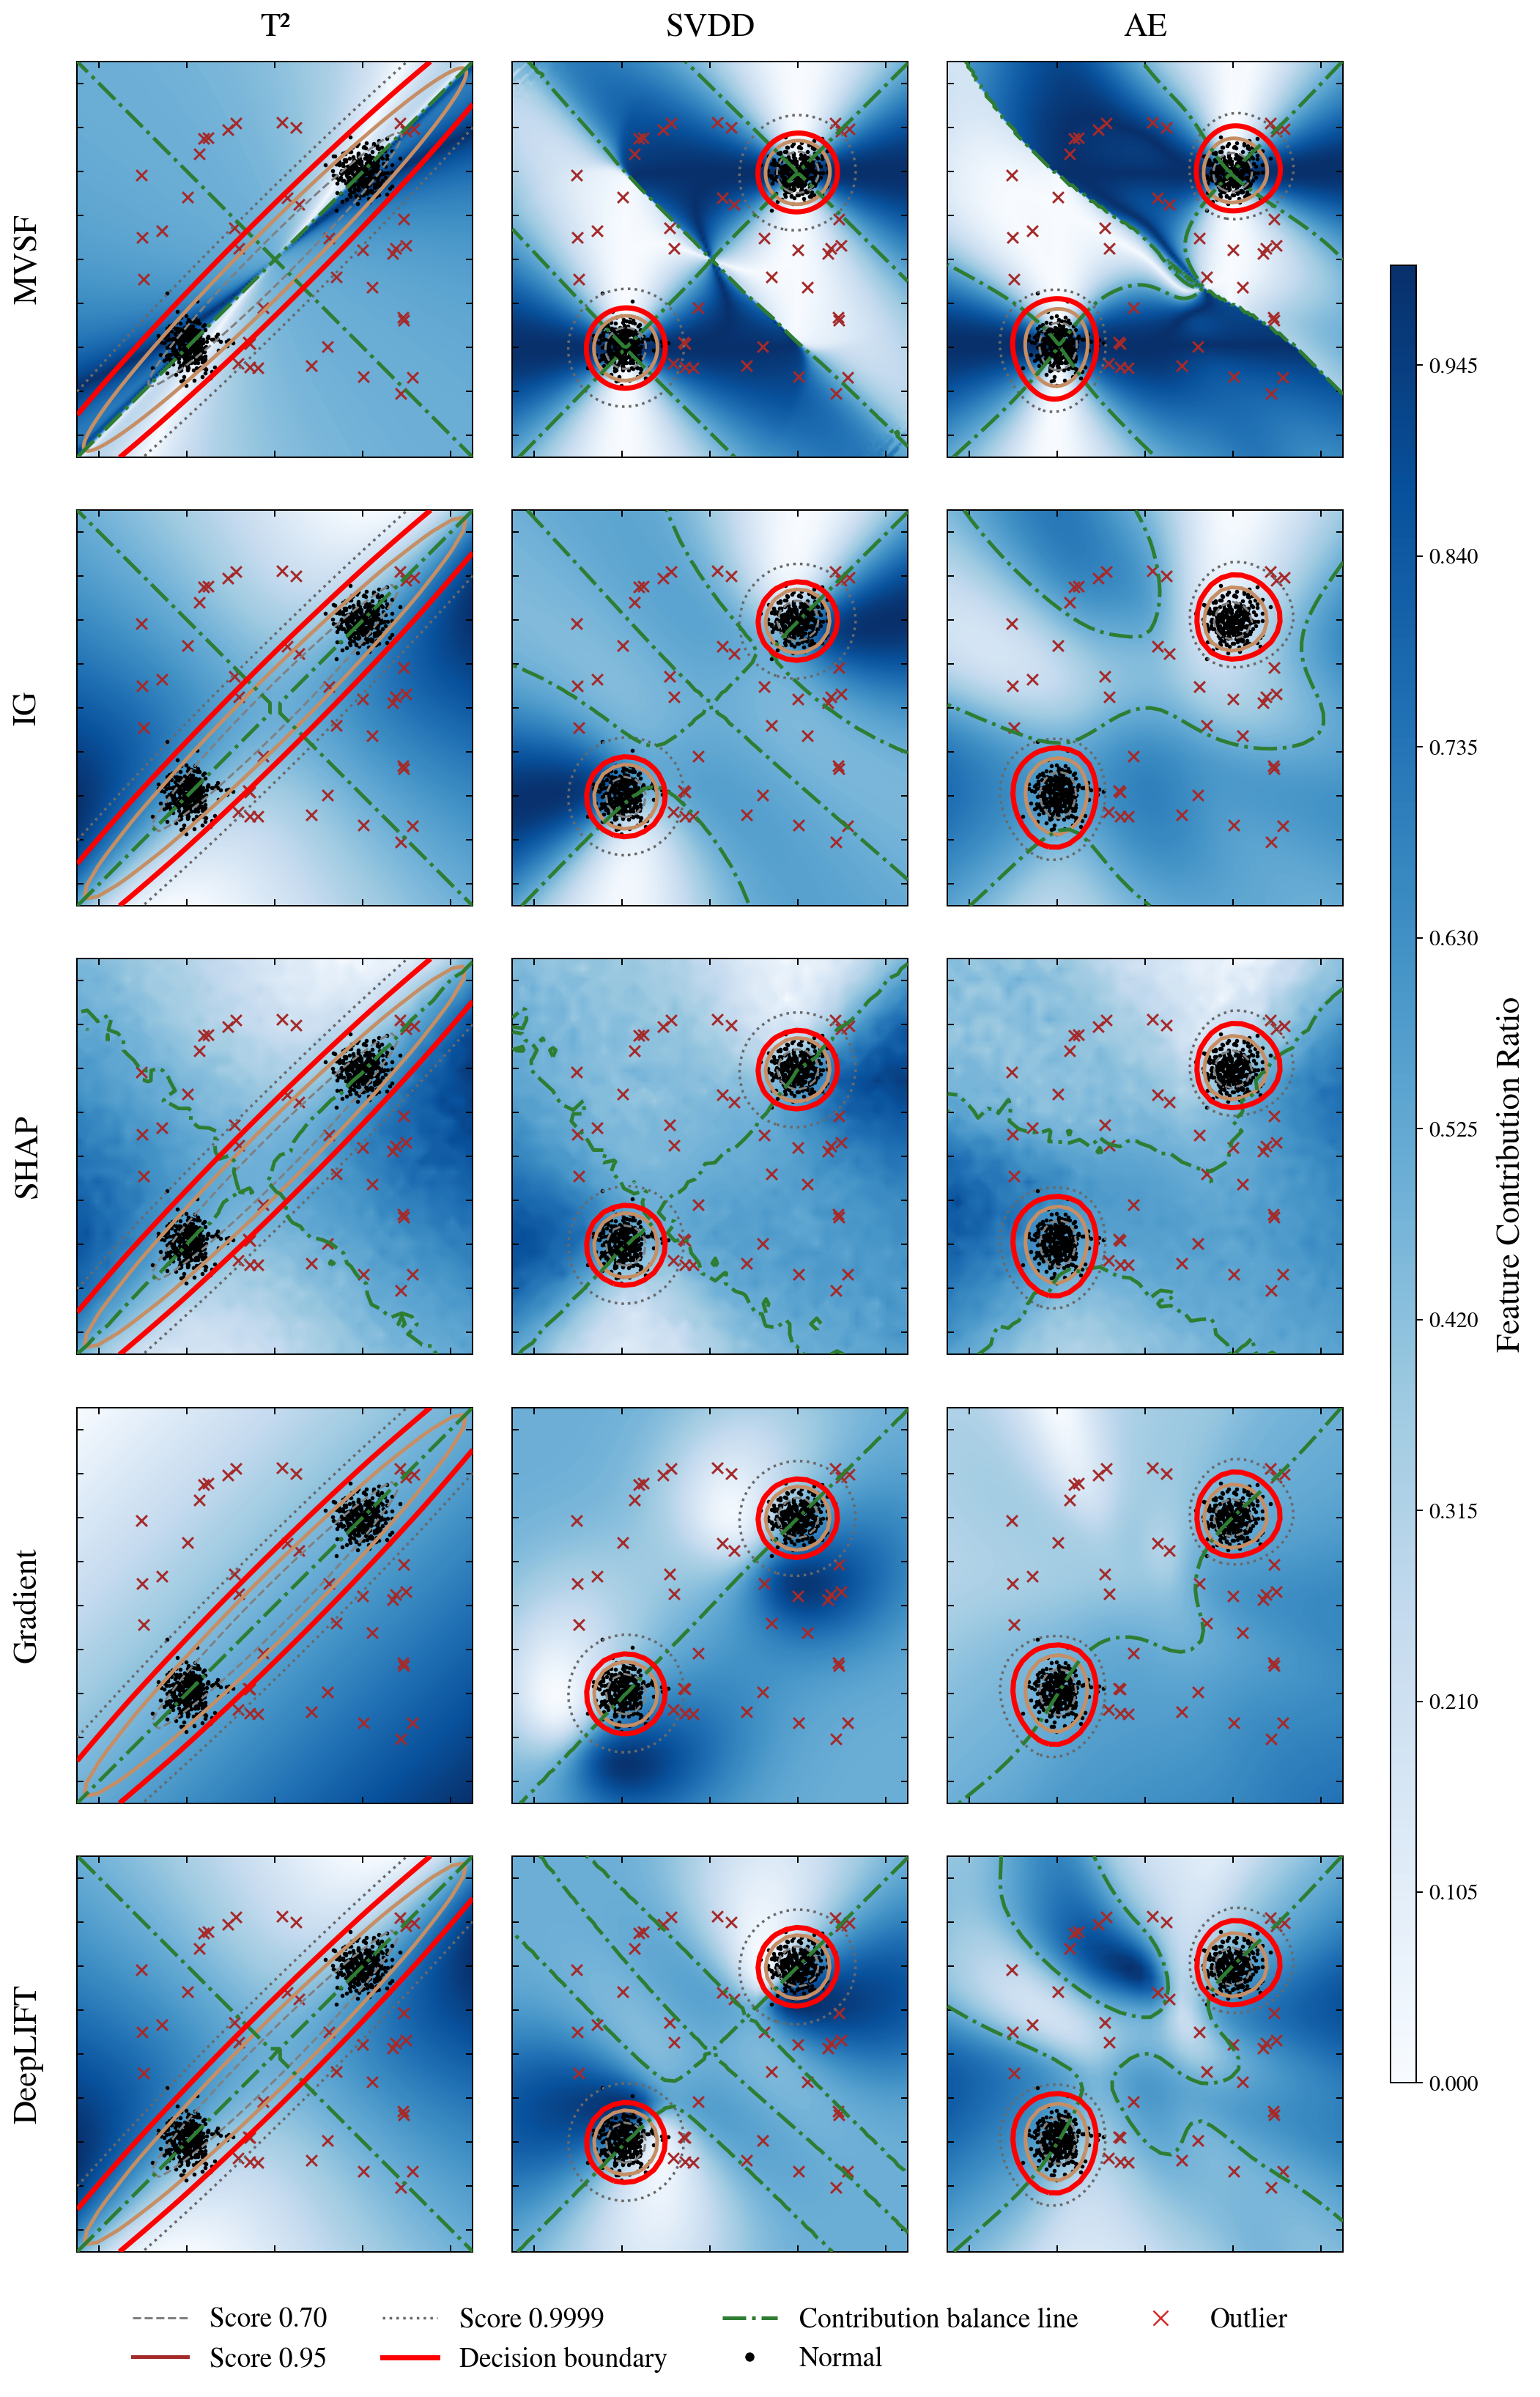

In [15]:
model_names = ["T²", "SVDD", "AE"]

method_labels = ["VSF", "IG", "SHAP", "Gradient", "DeepLIFT"]

plot_contribution_maps(
    model_names=model_names,
    method_labels=method_labels,
    feature_idx=0,
    x_normal=x_normal,
    x_outliers=x_outliers,
    models=models,
    thresholds=thresholds,
    reference_points=reference_points,
    config=CFG,
)